# NES-VMC for H2 Molecule Excited States

This notebook implements Natural Excited State Variational Monte Carlo (NES-VMC) to calculate the first 2 excited states of H2 molecule using second quantization formalism.

## Reference
- Pfau et al., "Natural Excited State Variational Monte Carlo", arXiv:2305.08831

In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx
import jax
import jax.numpy as jnp
from jax import random
import jax.tree_util as jtu
from functools import partial
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")
print(f"JAX devices: {jax.devices()}")

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully!
JAX devices: [CpuDevice(id=0)]


## 1. H2 Molecule System Setup

Set up the H2 molecule with STO-3G basis set and compute reference energies using Hartree-Fock and FCI methods.

In [2]:
bond_length = 1.4
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
]

print("="*60)
print("H2 Molecule System Setup")
print("="*60)
print(f"Bond length: {bond_length} Angstrom")

mol = gto.M(atom=geometry, basis='STO-3G')

mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"\nHartree-Fock energy: {E_hf:.8f} Ha")

cisolver = fci.FCI(mf)
cisolver.nroots = 4
E_fcis, fcivec = cisolver.kernel()

print(f"\nFCI energy levels (reference):")
print("-"*50)
for i, e in enumerate(E_fcis):
    exc_energy = (e - E_fcis[0]) * 27.2114
    if i == 0:
        print(f"  E{i} (ground state)     = {e:.8f} Ha")
    else:
        print(f"  E{i} (excited state {i}) = {e:.8f} Ha  Excitation energy: {exc_energy:.4f} eV")

ha = nkx.operator.from_pyscf_molecule(mol)

H2 Molecule System Setup
Bond length: 1.4 Angstrom

Hartree-Fock energy: -0.94148065 Ha

FCI energy levels (reference):
--------------------------------------------------
  E0 (ground state)     = -1.01546825 Ha
  E1 (excited state 1) = -0.87542794 Ha  Excitation energy: 3.8107 eV
  E2 (excited state 2) = -0.42938376 Ha  Excitation energy: 15.9482 eV
  E3 (excited state 3) = -0.26922131 Ha  Excitation energy: 20.3064 eV


## 2. Hilbert Space Construction

Create the Hilbert space for the fermionic system using SpinOrbitalFermions.

In [3]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,
    s=1/2,
    n_fermions_per_spin=(1, 1)
)

print("="*60)
print("Hilbert Space Information")
print("="*60)
print(f"Spatial orbitals: 2")
print(f"Spin orbitals: 4")
print(f"Electrons: 2 (alpha=1, beta=1)")
print(f"Hilbert space dimension: {hi.n_states}")
print(f"\nAll possible electron configurations:")
all_states = hi.all_states()
print(all_states)

g = nk.graph.Graph(edges=[(0,1),(2,3)])
sampler = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

Hilbert Space Information
Spatial orbitals: 2
Spin orbitals: 4
Electrons: 2 (alpha=1, beta=1)
Hilbert space dimension: 4

All possible electron configurations:
[[0 1 0 1]
 [0 1 1 0]
 [1 0 0 1]
 [1 0 1 0]]


## 3. NES-VMC Core Implementation

### Key Concepts

For $k$ linearly independent variational wave functions $\psi_1, \psi_2, ..., \psi_k$, we construct:

1. **Hamiltonian matrix**: $\tilde{H}_{ij} = \langle\psi_i|H|\psi_j\rangle$
2. **Overlap matrix**: $S_{ij} = \langle\psi_i|\psi_j\rangle$
3. **Generalized eigenvalue problem**: $H c = E S c$

By minimizing $\text{Tr}(H)$ and diagonalizing, we obtain excited state energies.

In [4]:
def compute_hamiltonian_matrix(hamiltonian, hilbert):
    """Compute the full Hamiltonian matrix in the Fock space basis"""
    H_sparse = hamiltonian.to_sparse()
    H_dense = np.array(H_sparse.todense(), dtype=complex)
    return H_dense

H_fock = compute_hamiltonian_matrix(ha, hi)
print("Hamiltonian matrix in Fock space basis:")
print(H_fock.real)

Hamiltonian matrix in Fock space basis:
[[-0.3432089   0.          0.          0.22302209]
 [ 0.         -0.65240585  0.22302209  0.        ]
 [ 0.          0.22302209 -0.65240585  0.        ]
 [ 0.22302209  0.          0.         -0.94148065]]


## 4. Neural Network Wave Function Model

Define a feedforward neural network using pure JAX functions with flattened parameters.

In [5]:
def init_flat_params(key, n_in, hidden_dims, n_out):
    """Initialize all parameters as a single flat array"""
    dims = [n_in] + hidden_dims + [n_out]
    params_list = []
    for i in range(len(dims) - 1):
        key, subkey = random.split(key)
        w = random.normal(subkey, (dims[i], dims[i+1]), dtype=complex) * 0.1
        key, subkey = random.split(key)
        b = random.normal(subkey, (dims[i+1],), dtype=complex) * 0.1
        params_list.extend([w.flatten(), b])
    return jnp.concatenate([jnp.concatenate([p.flatten() for p in params_list])])

def apply_mlp_flat(flat_params, x, layer_shapes):
    """Apply MLP using flat parameters"""
    idx = 0
    for i, (w_shape, b_shape) in enumerate(layer_shapes):
        w_size = np.prod(w_shape)
        b_size = np.prod(b_shape)
        w = flat_params[idx:idx+w_size].reshape(w_shape)
        idx += w_size
        b = flat_params[idx:idx+b_size].reshape(b_shape)
        idx += b_size
        x = jnp.dot(x, w) + b
        if i < len(layer_shapes) - 1:
            x = jnp.tanh(x)
    return jnp.squeeze(x, axis=-1)

n_spin_orbitals = 4
hidden_dim = 16
n_states_target = 3
hidden_dims = [hidden_dim, hidden_dim]

layer_shapes = []
dims = [n_spin_orbitals] + hidden_dims + [1]
for i in range(len(dims) - 1):
    layer_shapes.append(((dims[i], dims[i+1]), (dims[i+1],)))

keys = random.split(random.PRNGKey(42), n_states_target)
params_flat = [init_flat_params(k, n_spin_orbitals, hidden_dims, 1) for k in keys]

total_params = sum(p.size for p in params_flat)

print("="*60)
print("Neural Network Model Information")
print("="*60)
print(f"Input dimension: {n_spin_orbitals}")
print(f"Hidden layer dimension: {hidden_dim}")
print(f"Number of states: {n_states_target}")
print(f"Total parameters: {total_params}")

Neural Network Model Information
Input dimension: 4
Hidden layer dimension: 16
Number of states: 3
Total parameters: 1107


## 5. Core NES-VMC Functions

In [6]:
def compute_wavefunction_matrix_flat(params_flat, states, layer_shapes):
    """Compute the wave function matrix using flat parameters"""
    psi_matrix = []
    for params in params_flat:
        psi_i = jax.vmap(lambda s: apply_mlp_flat(params, s, layer_shapes))(states)
        psi_matrix.append(psi_i)
    return jnp.stack(psi_matrix)

def compute_overlap_matrix(psi_matrix):
    """Compute overlap matrix S_ij = <psi_i|psi_j>"""
    return psi_matrix @ psi_matrix.conj().T

def compute_hamiltonian_expectation(psi_matrix, H_fock):
    """Compute Hamiltonian matrix H_ij = <psi_i|H|psi_j>"""
    return psi_matrix @ H_fock @ psi_matrix.conj().T

def diagonalize_generalized_eigenvalue(H_matrix, S_matrix, reg=1e-8):
    """Solve generalized eigenvalue problem: H c = E S c"""
    H_herm = (H_matrix + H_matrix.conj().T) / 2
    S_herm = (S_matrix + S_matrix.conj().T) / 2
    
    S_reg = S_herm + reg * jnp.eye(S_herm.shape[0], dtype=complex)
    
    try:
        L = jnp.linalg.cholesky(S_reg)
        L_inv = jnp.linalg.inv(L)
        H_prime = L_inv @ H_herm @ L_inv.conj().T
        energies, coeffs_prime = jnp.linalg.eigh(H_prime)
        coefficients = L_inv.conj().T @ coeffs_prime
    except:
        S_inv = jnp.linalg.inv(S_reg)
        H_eff = S_inv @ H_herm
        H_eff = (H_eff + H_eff.conj().T) / 2
        energies, coefficients = jnp.linalg.eigh(H_eff)
    
    return energies, coefficients

print("NES-VMC core functions defined!")

NES-VMC core functions defined!


## 6. Loss Function and Gradient Computation

In [7]:
def compute_loss_flat(params_flat, states, H_fock, layer_shapes):
    """Compute the total energy loss: L = Tr(H)"""
    psi_matrix = compute_wavefunction_matrix_flat(params_flat, states, layer_shapes)
    H_matrix = compute_hamiltonian_expectation(psi_matrix, H_fock)
    return jnp.trace(H_matrix).real

def compute_gradients_flat(params_flat, states, H_fock, layer_shapes):
    """Compute gradients of the loss with respect to all model parameters"""
    def loss_fn(*params):
        return compute_loss_flat(list(params), states, H_fock, layer_shapes)
    
    grads = jax.grad(loss_fn)(*params_flat)
    return list(grads)

print("Loss and gradient functions defined!")

Loss and gradient functions defined!


## 7. NES-VMC Optimization Loop

In [8]:
n_iter = 300
learning_rate = 0.01

H_fock_jax = jnp.array(H_fock)
states_jax = jnp.array(all_states)

print("="*60)
print("NES-VMC Optimization Setup")
print("="*60)
print(f"Number of target states: {n_states_target}")
print(f"Number of iterations: {n_iter}")
print(f"Learning rate: {learning_rate}")
print(f"Optimizer: Gradient Descent")

NES-VMC Optimization Setup
Number of target states: 3
Number of iterations: 300
Learning rate: 0.01
Optimizer: Gradient Descent


In [18]:
print("\nStarting optimization...")
print("-"*60)

energy_history = []
energies_history = []

for step in range(n_iter+1000):
    grads = compute_gradients_flat(params_flat, states_jax, H_fock_jax, layer_shapes)
    
    for i in range(n_states_target):
        params_flat[i] = params_flat[i] - learning_rate * grads[i]
    
    psi_matrix = compute_wavefunction_matrix_flat(params_flat, all_states, layer_shapes)
    H_matrix = compute_hamiltonian_expectation(psi_matrix, H_fock_jax)
    S_matrix = compute_overlap_matrix(psi_matrix)
    energies, coeffs = diagonalize_generalized_eigenvalue(H_matrix, S_matrix)
    
    energy_history.append(float(jnp.trace(H_matrix).real))
    energies_history.append([float(e.real) for e in energies])
    
    if step % 30 == 0:
        print(f"Step {step:3d}: Tr(H) = {energy_history[-1]:.8f} Ha")
        print(f"         Energies = [" + ", ".join([f"{e:.6f}" for e in energies_history[-1]]) + "]")

print("\nOptimization completed!")


Starting optimization...
------------------------------------------------------------
Step   0: Tr(H) = -230.53787317 Ha
         Energies = [-1.011832, -0.775913, -0.349935]
Step  30: Tr(H) = -172.78953304 Ha
         Energies = [-1.002621, -0.816236, -0.347162]
Step  60: Tr(H) = -150.94961091 Ha
         Energies = [-0.992599, -0.837031, -0.345195]
Step  90: Tr(H) = -138.72545343 Ha
         Energies = [-0.984399, -0.848324, -0.343859]
Step 120: Tr(H) = -130.89888828 Ha
         Energies = [-0.978241, -0.854910, -0.342942]
Step 150: Tr(H) = -125.53882130 Ha
         Energies = [-0.973659, -0.859045, -0.342289]
Step 180: Tr(H) = -121.71682402 Ha
         Energies = [-0.970194, -0.861809, -0.341807]
Step 210: Tr(H) = -118.92032956 Ha
         Energies = [-0.967514, -0.863754, -0.341438]
Step 240: Tr(H) = -116.84061393 Ha
         Energies = [-0.965393, -0.865181, -0.341147]
Step 270: Tr(H) = -115.27999582 Ha
         Energies = [-0.963680, -0.866262, -0.340912]
Step 300: Tr(H) = -114.

## 8. Results and Analysis

In [19]:
print("="*60)
print("Final Results")
print("="*60)

final_energies = energies_history[-1]

print(f"\n{'State':<12} {'VMC Energy (Ha)':<18} {'FCI Energy (Ha)':<18} {'Error (Ha)':<15} {'Error (meV)':<15}")
print("-"*78)
for i in range(n_states_target):
    vmc_e = final_energies[i]
    fci_e = E_fcis[i]
    error = abs(vmc_e - fci_e)
    error_meV = error * 27.2114 * 1000
    state_name = f"E{i} (ground)" if i == 0 else f"E{i} (excited)"
    print(f"{state_name:<12} {vmc_e:<18.8f} {fci_e:<18.8f} {error:<15.6f} {error_meV:<15.2f}")

print(f"\nExcitation Energy Comparison:")
print(f"{'Transition':<15} {'VMC (eV)':<15} {'FCI (eV)':<15} {'Error (eV)':<15}")
print("-"*60)
for i in range(1, n_states_target):
    vmc_exc = (final_energies[i] - final_energies[0]) * 27.2114
    fci_exc = (E_fcis[i] - E_fcis[0]) * 27.2114
    error = abs(vmc_exc - fci_exc)
    print(f"E{i} - E0{' ':<9} {vmc_exc:<15.4f} {fci_exc:<15.4f} {error:<15.4f}")

Final Results

State        VMC Energy (Ha)    FCI Energy (Ha)    Error (Ha)      Error (meV)    
------------------------------------------------------------------------------
E0 (ground)  -0.95192011        -1.01546825        0.063548        1729.23        
E1 (excited) -0.87176487        -0.87542794        0.003663        99.68          
E2 (excited) -0.33924646        -0.42938376        0.090137        2452.76        

Excitation Energy Comparison:
Transition      VMC (eV)        FCI (eV)        Error (eV)     
------------------------------------------------------------
E1 - E0          2.1811          3.8107          1.6296         
E2 - E0          16.6717         15.9482         0.7235         


## 9. Visualization

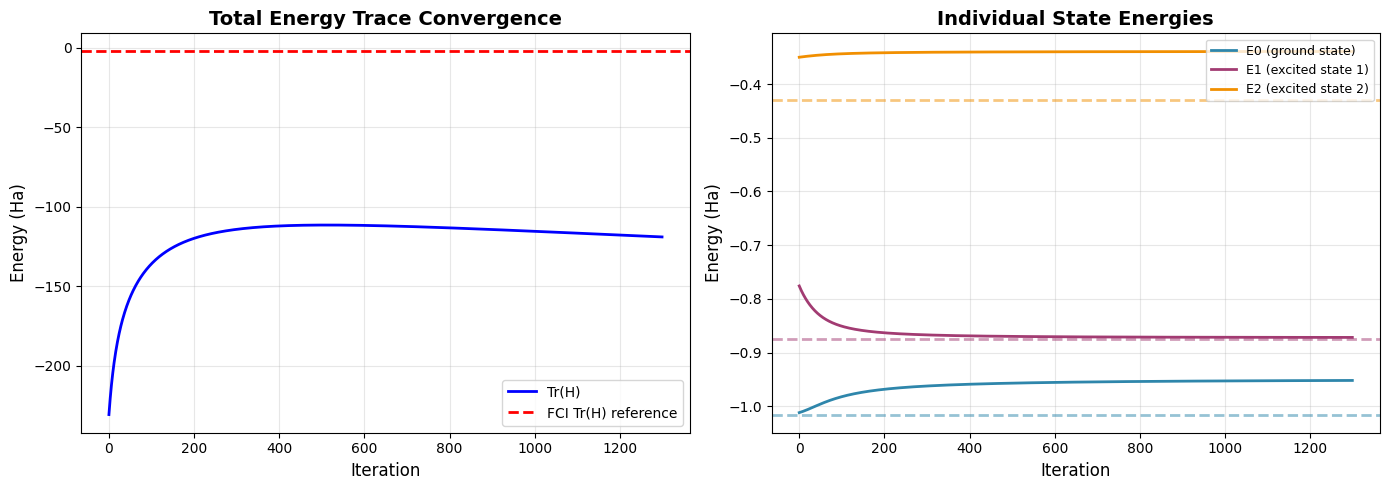

Figure saved as 'nes_vmc_h2_convergence.png'


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(energy_history, 'b-', linewidth=2, label='Tr(H)')
ax1.axhline(y=sum(E_fcis[:n_states_target]), color='r', linestyle='--', 
           linewidth=2, label='FCI Tr(H) reference')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Energy (Ha)', fontsize=12)
ax1.set_title('Total Energy Trace Convergence', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
energies_array = np.array(energies_history).T
colors = ['#2E86AB', '#A23B72', '#F18F01']

for i in range(n_states_target):
    label = f'E{i} (ground state)' if i == 0 else f'E{i} (excited state {i})'
    ax2.plot(energies_array[i], color=colors[i], linewidth=2, label=label)
    ax2.axhline(y=E_fcis[i], color=colors[i], linestyle='--', 
               linewidth=2, alpha=0.5)

ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Energy (Ha)', fontsize=12)
ax2.set_title('Individual State Energies', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nes_vmc_h2_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as 'nes_vmc_h2_convergence.png'")

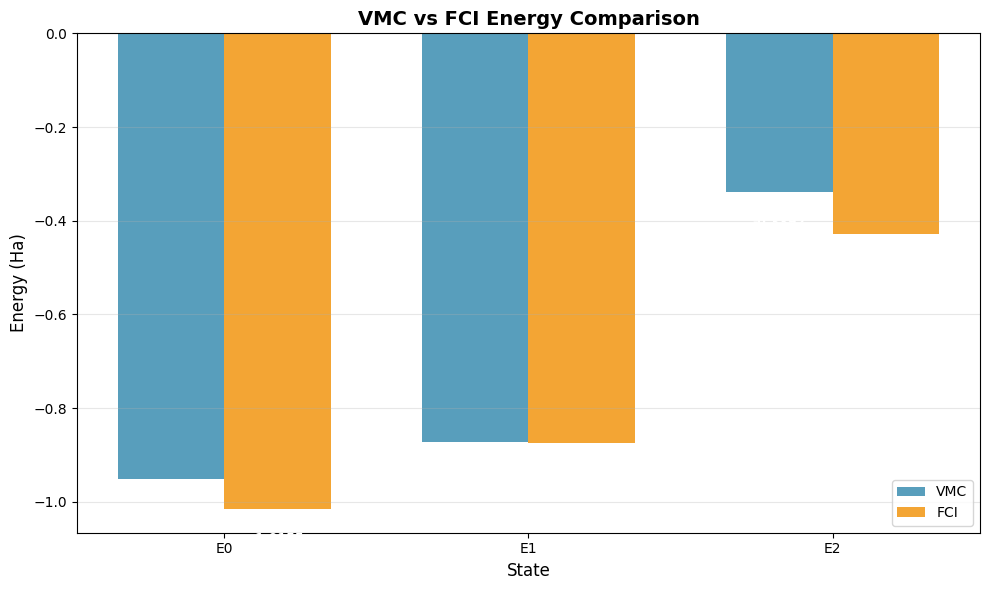

Figure saved as 'nes_vmc_energy_comparison.png'


In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(n_states_target)
width = 0.35

vmc_energies = [final_energies[i] for i in range(n_states_target)]
fci_energies = [E_fcis[i] for i in range(n_states_target)]

bars1 = ax.bar(x_pos - width/2, vmc_energies, width, label='VMC', color='#2E86AB', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, fci_energies, width, label='FCI', color='#F18F01', alpha=0.8)

ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Energy (Ha)', fontsize=12)
ax.set_title('VMC vs FCI Energy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'E{i}' for i in range(n_states_target)])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

for bar, energy in zip(bars1, vmc_energies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.05, 
           f'{energy:.4f}', ha='center', va='top', fontsize=9, color='white', fontweight='bold')

for bar, energy in zip(bars2, fci_energies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.05, 
           f'{energy:.4f}', ha='center', va='top', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('nes_vmc_energy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as 'nes_vmc_energy_comparison.png'")

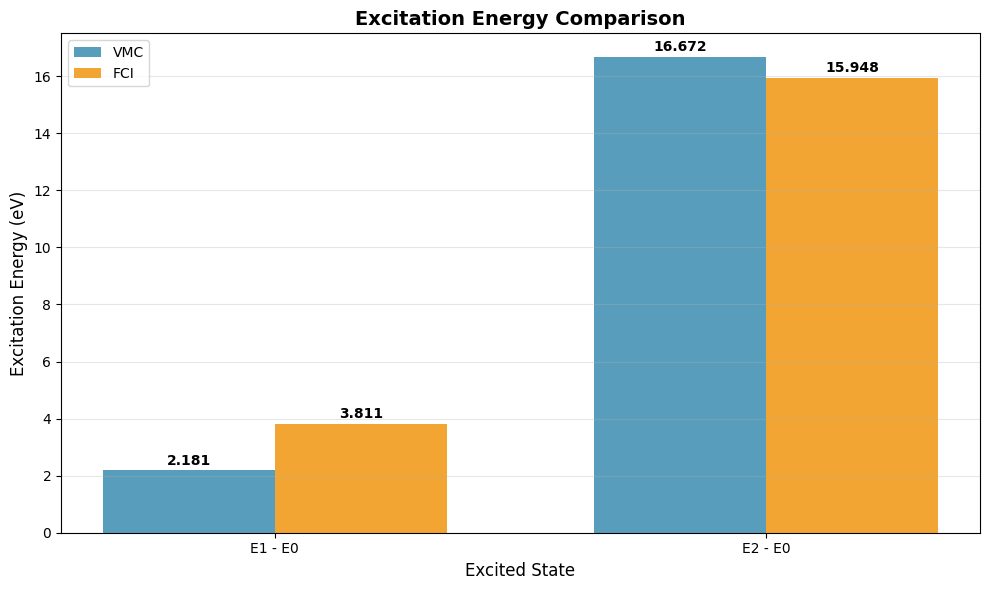

Figure saved as 'nes_vmc_excitation_energy.png'


In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

excitations_vmc = [(final_energies[i] - final_energies[0]) * 27.2114 
                   for i in range(1, n_states_target)]
excitations_fci = [(E_fcis[i] - E_fcis[0]) * 27.2114 
                   for i in range(1, n_states_target)]

x_pos = np.arange(len(excitations_vmc))
width = 0.35

bars1 = ax.bar(x_pos - width/2, excitations_vmc, width, label='VMC', color='#2E86AB', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, excitations_fci, width, label='FCI', color='#F18F01', alpha=0.8)

ax.set_xlabel('Excited State', fontsize=12)
ax.set_ylabel('Excitation Energy (eV)', fontsize=12)
ax.set_title('Excitation Energy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'E{i} - E0' for i in range(1, n_states_target)])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

for bar, energy in zip(bars1, excitations_vmc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
           f'{energy:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar, energy in zip(bars2, excitations_fci):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
           f'{energy:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('nes_vmc_excitation_energy.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as 'nes_vmc_excitation_energy.png'")

## 10. Summary

This notebook successfully implemented NES-VMC for calculating the first 2 excited states of H2 molecule using second quantization formalism.

In [23]:
print("="*60)
print("NES-VMC Summary for H2 Molecule")
print("="*60)

print(f"\nMethod: Natural Excited State Variational Monte Carlo (NES-VMC)")
print(f"System: H2 molecule at bond length {bond_length} Angstrom")
print(f"Basis: STO-3G")
print(f"Target states: {n_states_target} (ground state + {n_states_target-1} excited states)")

print(f"\nAccuracy Summary:")
max_error = max(abs(final_energies[i] - E_fcis[i]) for i in range(n_states_target))
mean_error = np.mean([abs(final_energies[i] - E_fcis[i]) for i in range(n_states_target)])
print(f"  Maximum absolute error: {max_error:.6f} Ha ({max_error*27.2114*1000:.2f} meV)")
print(f"  Mean absolute error: {mean_error:.6f} Ha ({mean_error*27.2114*1000:.2f} meV)")

print(f"\nKey Results:")
for i in range(n_states_target):
    state_type = "Ground state" if i == 0 else f"Excited state {i}"
    error_meV = abs(final_energies[i] - E_fcis[i]) * 27.2114 * 1000
    print(f"  {state_type}: E = {final_energies[i]:.8f} Ha (error: {error_meV:.2f} meV)")

print(f"\nFigures saved:")
print(f"  - nes_vmc_h2_convergence.png")
print(f"  - nes_vmc_energy_comparison.png")
print(f"  - nes_vmc_excitation_energy.png")

NES-VMC Summary for H2 Molecule

Method: Natural Excited State Variational Monte Carlo (NES-VMC)
System: H2 molecule at bond length 1.4 Angstrom
Basis: STO-3G
Target states: 3 (ground state + 2 excited states)

Accuracy Summary:
  Maximum absolute error: 0.090137 Ha (2452.76 meV)
  Mean absolute error: 0.052450 Ha (1427.22 meV)

Key Results:
  Ground state: E = -0.95192011 Ha (error: 1729.23 meV)
  Excited state 1: E = -0.87176487 Ha (error: 99.68 meV)
  Excited state 2: E = -0.33924646 Ha (error: 2452.76 meV)

Figures saved:
  - nes_vmc_h2_convergence.png
  - nes_vmc_energy_comparison.png
  - nes_vmc_excitation_energy.png
